## Q1: Kamrad–Ritchken parametrisation in Different Options

We consider a **trinomial tree model** where the discrete stock price process $S_n$ follows
$$
S_n = S_0 \prod_{i = 1}^n \xi_i
$$

with the $\xi$'s being i.i.d. random variables defined via

$$
\xi_i =
\begin{cases}
u, & \text{with probability } q_u \\
m, & \text{with probability } q_m \\
d, & \text{with probability } q_d
\end{cases}
$$
and the parameters satisfy $d<m<u$ and $q_u + q_m + q_d = 1$.

In the **Kamrad–Ritchken parametrisation**, we have

$$
u = e^{\lambda \sigma \sqrt{\Delta t}},
\qquad
m = 1,
\qquad
d = e^{-\lambda \sigma \sqrt{\Delta t}}
$$
and

$$
q_u = \frac{1}{2\lambda^2}
+ \frac{\left(r - \frac{\sigma^2}{2}\right)\sqrt{\Delta t}}{2\lambda\sigma},
\qquad
q_m = 1 - \frac{1}{\lambda^2},
\qquad
q_d = \frac{1}{2\lambda^2}
- \frac{\left(r - \frac{\sigma^2}{2}\right)\sqrt{\Delta t}}{2\lambda\sigma}.
$$

Here $\lambda \geq 1$ is a free parameter.

In the following 3 tasks, we are going to assume

- No dividend;
- Volatility $\sigma = 20\% = 0.2$;
- Risk-free rate $r = 1\% = 0.01$;
- Maturity $T = 1$ year.

### Set-up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# Get the parameters given lambda, volatility, number of steps, maturity and risk-free rate.
def GetTrinomialKRPara(lamb, sigma, N, T, r):
    dt = T / N
    u = np.exp(lamb * sigma * np.sqrt(dt))
    m = 1.
    d = np.exp(-lamb * sigma * np.sqrt(dt))
    qu = (1. / (2. * lamb ** 2)) + ((r - (sigma ** 2) / 2.) * np.sqrt(dt) / (2. * lamb * sigma))
    qm = 1. - (1. / lamb ** 2)
    qd = (1. / (2. * lamb ** 2)) - ((r - (sigma ** 2) / 2.) * np.sqrt(dt) / (2. * lamb * sigma))
    R = np.exp(r * dt)
    return u, m, d, qu, qm, qd, R

### Task 1: European Option

#### Part (a)

At Step $n$ ($n \leq N$), the stock price is
$$
S^n_{i,j,k} = S_0 u^i m^j d^k
$$
where $i + j + k = n$.

The European option payoff functions are
        \begin{align}
		\text{Call option:}\qquad &g(S_T) = (S_T - K)^+ \\
		\text{Put option:}\qquad &g(S_T) = (K - S_T)^+
		\end{align}
Naively, we can use the same idea in the **NB 1.1 Binomial Tree** notebook provided in the course, which is the **backward induction**:
1. Compute the option price at the terminal time $N$ which is simply the option payoff function:
		\begin{align}
		V^N_{i,k} = g(S^N_{i,k}) \quad \text{for each }i, k=0,1,...,N \text{ and } i + k \leq N
		\end{align}
2. Loop backward in time: for $n=N-1,N-2,...,0$, compute
		\begin{align*}
		\text{European option: }V^{n}_k&=e^{-r\triangle t}[q_uV^{n+1}_{i + 1, k} + q_mV^{n+1}_{i, k} + q_dV^{n+1}_{i, k+1}]\quad\text{for each }k=0,1,...,n \\
		\end{align*}

But this method has a complexity of $O(N^3)$, which is not efficient.

### Optimise the backward induction algorithm
Notice that we have $d = u^{-1}$ and $m = 1$. Therefore, we could rewrite the formula of the stock price as
$$
S^n_{i,j,k} = S_0 u^i m^j d^k = S_0 u^{i - k}
$$
where $i - k \in \{-n, -n+1, \dots, -1, 0, 1, \dots, n-1, n\}$.

Let $p = i - k$ be the **relative displacement**, then the above idea can be modified as:
1. Compute the option price at the terminal time $N$:
		\begin{align}
		V^N_{p} = g(S^N_{p}) \quad \text{for each }p =-N,...,N
		\end{align}
2. Loop backward in time: for $n=N-1,N-2,...,0$, compute
		\begin{align*}
		\text{European option: }V^{n}_p&=e^{-r\triangle t}[q_uV^{n+1}_{p+1} + q_mV^{n+1}_{p} + q_dV^{n+1}_{p-1}]\quad\text{for each }k=0,1,...,n \\
		\end{align*}
3. Output $V^0_0$.

This algorithm has a complexity of $O(N^2)$.

#### Part (b)

In [3]:
# Create the trinomial tree.
def TrinomialTree(S0, u, qu, qm, qd, R, N, payoff):

    # Create an empty arrays to store the stock price and option value at each node
    V = np.zeros((2 * N + 1, N + 1))
    S = np.zeros((2 * N + 1, N + 1))

    # Set up S[p,n] = S0 * u^p for p = -n, -n+1, ..., n
    for n in range(N + 1):
      S[N - n:N + n + 1, n] = S0 * u**np.arange(n, -n - 1, -1)

    # Compute the option price at terminal time
    V[:,N] = payoff(S[:,N])

    # Loop backward in time
    for t in reversed(range(N)):
        V[N - t:N + t + 1, t] = (qu * V[N-t-1:N+t,t+1] + qm * V[N - t:N+t+1, t+1] + qd * V[N-t+1:N+t+2, t+1]) / R

    return V, S     # get the function to return the whole tree of stock prices and option values

def GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, payoff):
    V,S = TrinomialTree(S0, u, qu, qm, qd, R, N, payoff)
    return V[N,0]

# Black–Scholes European call option price
def BS_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

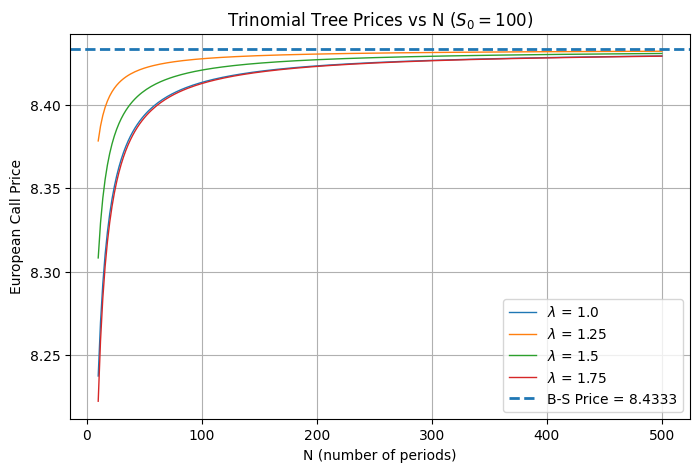

In [4]:
sigma, T, r = 0.2, 1., 0.01
K, S0= 100., 100.

PutPayoff = lambda x : np.maximum(K - x, 0) # Payoff of a European put option.
CallPayoff = lambda x : np.maximum(x - K, 0) # Payoff of a European call option.

lambda_list = [1., 1.25, 1.5, 1.75]
N_list = list(range(10, 501, 2))

plt.figure(figsize=(8, 5))

for lam in lambda_list:
    prices = []
    for N in N_list:
        u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)
        price = GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, CallPayoff)
        prices.append(price)

    plt.plot(N_list, prices, linewidth=1, label=rf"$\lambda$ = {lam}")

bs_price = BS_call_price(S0, K, r, sigma, T)
plt.axhline(bs_price, linestyle="--", linewidth=2, label=f"B-S Price = {bs_price:.4f}")

plt.xlabel("N (number of periods)")
plt.ylabel("European Call Price")
plt.title("Trinomial Tree Prices vs N ($S_0 = 100$)")
plt.legend()
plt.grid(True)
plt.savefig("Part(b).png", dpi=300, bbox_inches="tight")
plt.show()

One may observe that as $N$ increases, the prices of European call option under all different values of $\lambda$ converges to the Black-Scholes price:
$$
C(S_0,K,r,\sigma,T)
= S_0\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2),
$$

where

$$
        \begin{align*}
		&d_1 = \frac{\ln\!\left(\frac{S_0}{K}\right) + \left(r+\frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}} \\
		&d_2 = d_1 - \sigma\sqrt{T},
		\end{align*}
$$

One may also observe that when $\lambda = 1.25$, the numerical solution converges to the Black-Scholes price fastest.

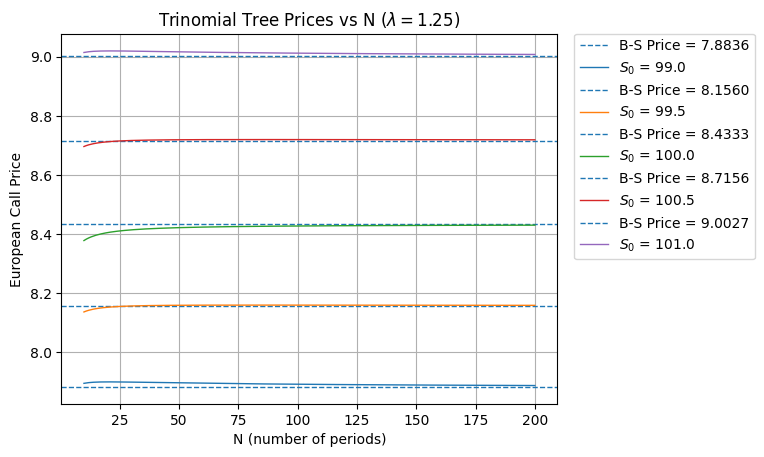

In [28]:
lam = 1.25
S0_list = np.linspace(99,101,5)
N_list = list(range(10, 201, 1))
for S0 in S0_list:
    prices = []
    for N in N_list:
        u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)
        price = GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, CallPayoff)
        prices.append(price)
    bs_price = BS_call_price(S0, K, r, sigma, T)
    plt.axhline(bs_price, linestyle="--", linewidth=1, label=f"B-S Price = {bs_price:.4f}")
    plt.plot(N_list, prices, linewidth=1, label=rf"$S_0$ = {S0}")

# bs_price = BS_call_price(S0, K, r, sigma, T)
# plt.axhline(bs_price, linestyle="--", linewidth=2, label=f"B-S Price = {bs_price:.4f}")

plt.xlabel("N (number of periods)")
plt.ylabel("European Call Price")
plt.title(rf"Trinomial Tree Prices vs N ($\lambda = 1.25$)")
plt.legend(loc = 'upper left', bbox_to_anchor = (1.02,1.02))
plt.grid(True)
plt.savefig('Part(b)_2.png', dpi=300, bbox_inches="tight")
plt.show()

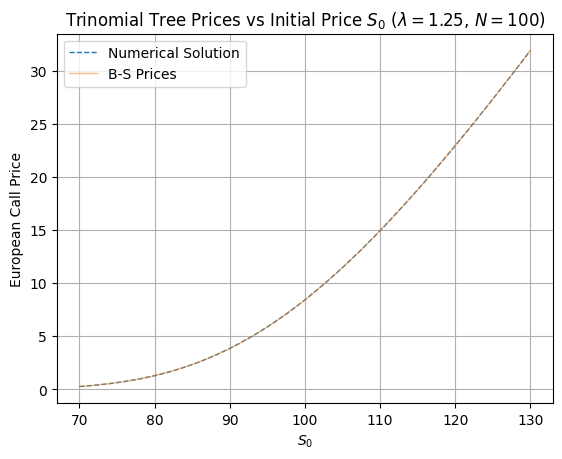

In [14]:
lam, N = 1.25, 100
S0_list = np.linspace(70,130,121)
prices = []
bs_prices = []
for S0 in S0_list:
    u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)
    price = GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, CallPayoff)
    prices.append(price)
    bs_prices.append(BS_call_price(S0, K, r, sigma, T))
plt.plot(S0_list, prices, linewidth=1, alpha = 1, label = 'Numerical Solution', linestyle="--")
plt.plot(S0_list, bs_prices, linewidth = 1, alpha = 0.5, label = 'B-S Prices')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("European Call Price")
plt.title(rf"Trinomial Tree Prices vs Initial Price $S_0$ ($\lambda = {lam}$, $N = {N}$)")
plt.grid(True)
plt.savefig('Part(b)_3.png', dpi=300, bbox_inches="tight")
plt.show()

From the figures above, one may conclude that

- change in $S_0$ does not influence the speed of convergence;
- the numerical solution of the option price increases as $S_0$ increases.

#### Part (c)

In [7]:
N, K = 500, 100
CallPayoff = lambda x : np.maximum(x - K, 0)

# Take 100 values for S_0
S0_list = np.linspace(70,130,100)
lambda_list = [1.0, 1.25, 1.5, 1.75]
rows = []
for S0 in S0_list:
    bs = BS_call_price(S0, K, r, sigma, T)
    for lam in lambda_list:
        u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)
        tri = GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, CallPayoff)
        diff = tri - bs
        rows.append({
            "S0": float(S0),
            "lambda": lam,
            "Trinomial": float(tri),
            "BlackScholes": float(bs),
            "Diff (Tri - BS)": float(diff),
            "Abs Diff": float(abs(diff)),
        })

df = pd.DataFrame(rows)

pivot_diff = df.pivot(index="S0", columns="lambda", values="Diff (Tri - BS)")
pivot_abs  = df.pivot(index="S0", columns="lambda", values="Abs Diff")


In [8]:
pivot_abs.head()

lambda,1.00,1.25,1.50,1.75
S0,,,,
70.000000,0.001211,0.000595,0.000036,0.000038
70.606061,0.000078,0.000563,0.000619,0.000061
71.212121,0.001589,0.000257,0.000061,0.000280
71.818182,0.000023,0.000216,0.000007,0.000233
72.424242,0.001651,0.000553,0.000772,0.000456


In [9]:
pivot_abs.describe()

lambda,1.00,1.25,1.50,1.75
count,100.000000,100.000000,100.000000,100.000000
mean,0.001508,0.000759,0.000886,0.001106
std,0.001127,0.000529,0.000572,0.000774
min,0.000023,0.000005,0.000002,0.000031
25%,0.000498,0.000344,0.000451,0.000544
50%,0.001327,0.000702,0.000831,0.000970
75%,0.002356,0.001101,0.001233,0.001522
max,0.003924,0.001885,0.002392,0.003491


From the data above, one may observe that both the **mean** and **variance** of the absolute differences between numerical and B-S prices under 100 different values of $S_0 \in \left[70,130\right]$ when $\lambda = 1.25$ is the smallest among the 4 values. Also, we have observed that the speed of convergence is also the fastest when $\lambda = 1.25$ from Part (b).

Hence for the rest of Task 1, we will use $\lambda = 1.25$.

### Task 2: American Options

#### Part (a)

The algorithm for the American options is quite similar as the European options, but there should be some modifications:

1. Since the payoff of American option at maturity is the same as the payoff of European option, we initialise in the same way:
		\begin{align}
		V^N_{p} = g(S^N_{p}) \quad \text{for each }p =-N,...,N
		\end{align}
2. In the backward loop, since we have the right but not the obligation to exercise the option at any time, then for $n=N-1,N-2,...,0$, compute
		\begin{align*}
		\text{American option: }V^{n}_p&=\max(g(S^n_p), e^{-r\triangle t}[q_uV^{n+1}_{p+1} + q_mV^{n+1}_{p} + q_dV^{n+1}_{p-1}])\quad\text{for each }p=0,1,...,n \\
		\end{align*}
3. Output $V^0_0$.

The **intrinsic value** at time $n$ and relative displacement $p$ is $g(S^n_p)$.

This algorithm has a complexity of $O(N^2)$.

#### Part (b)

In [10]:
def AmericanTrinomialPrice(S0, sigma, T, r, N, lam, payoff):

    u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)

    V = np.zeros((2 * N + 1, N + 1))
    S = np.zeros((2 * N + 1, N + 1))

    for n in range(N + 1):
        S[N - n:N + n + 1, n] = S0 * (u ** np.arange(n, -n - 1, -1))

    # Compute the option price at terminal time
    V[:,N] = payoff(S[:,N])
    # backward induction with early exercise
    for t in reversed(range(N)):
        hold_option = (qu * V[N-t-1:N+t,t+1] + qm * V[N - t:N+t+1, t+1] + qd * V[N-t+1:N+t+2, t+1]) / R

        # intrinsic value at time t
        exercise_option = payoff(S[N - t:N + t + 1, t])
        V[N - t:N + t + 1, t] = np.maximum(exercise_option, hold_option)

    return V  # time-0 value

def GetAmerOptionPrice(S0, sigma, T, r, N, lam, payoff):
    V = AmericanTrinomialPrice(S0, sigma, T, r, N, lam, payoff)
    return V[N,0]



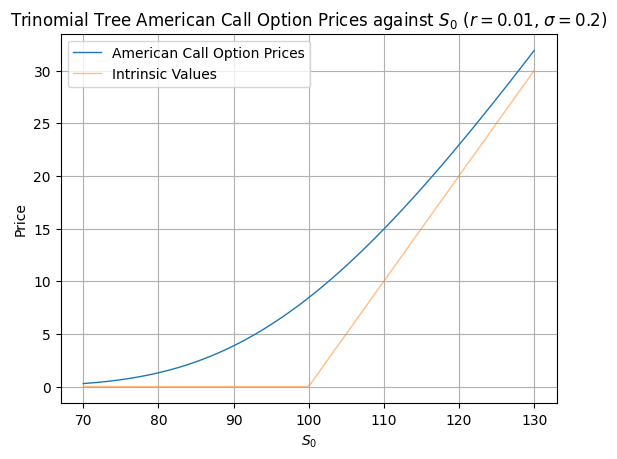

In [11]:
lam, K, N = 1.25, 100, 500
sigma, T, r = 0.2, 1., 0.01

S0_list = np.linspace(70,130,200)
PutPayoff = lambda x : np.maximum(K - x, 0) # Payoff of put option.
CallPayoff = lambda x : np.maximum(x - K, 0) # Payoff of call option.

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, CallPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(S0, K) - K
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Call Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Call Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_b.png', dpi = 300, bbox_inches="tight")

One may observe that the American call option prices at all $S_0 \in \left[70,130\right]$ are greater than the initial intrinsic values. This suggests we shall never exercise the option at time $t = 0$ regardless of $S_0$.

#### Part (c)

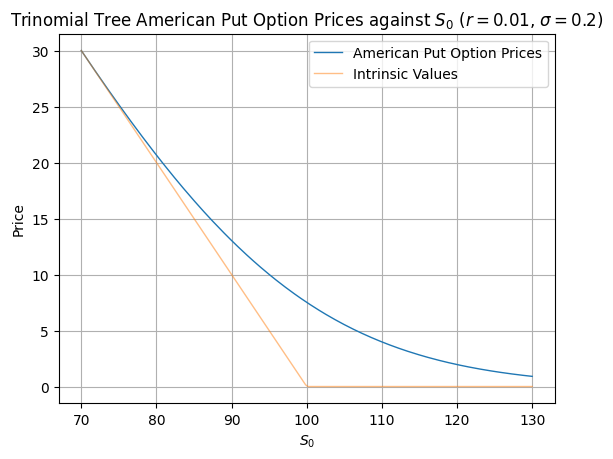

In [12]:
amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.01_sigma_0.2.png', dpi = 300, bbox_inches="tight")


One may find out from the figure above that

- the option prices are still higher than the intrinsic values when $S_0 \geq 75$ roughly;
- when $S_0 \leq 75$, the option prices are almost the same as the intrinsic values, indicating that it might be a good idea to exercise the option at time $t = 0$.

This is our new optimal early exercise strategy at time $0$ for the American put option.

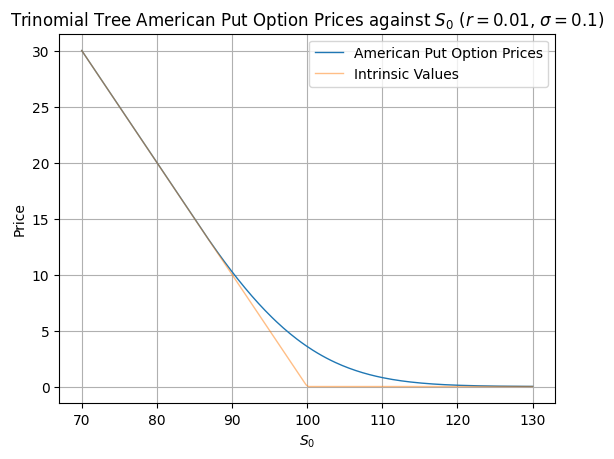

In [31]:
sigma = 0.1
r = 0.01

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.01_sigma_0.1.png', dpi = 300, bbox_inches="tight")

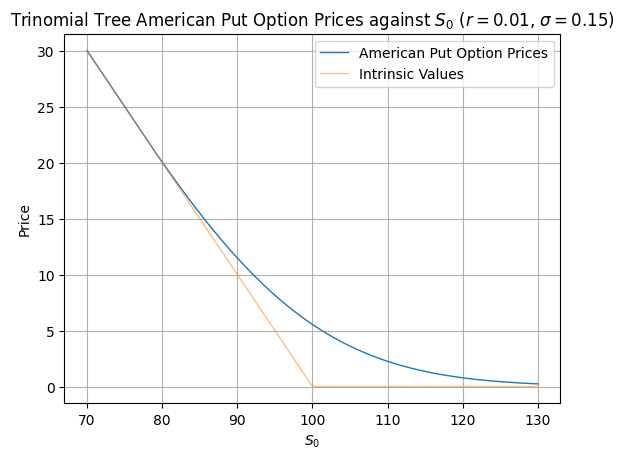

In [32]:
sigma = 0.15
r = 0.01

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.01_sigma_0.15.png', dpi = 300, bbox_inches="tight")

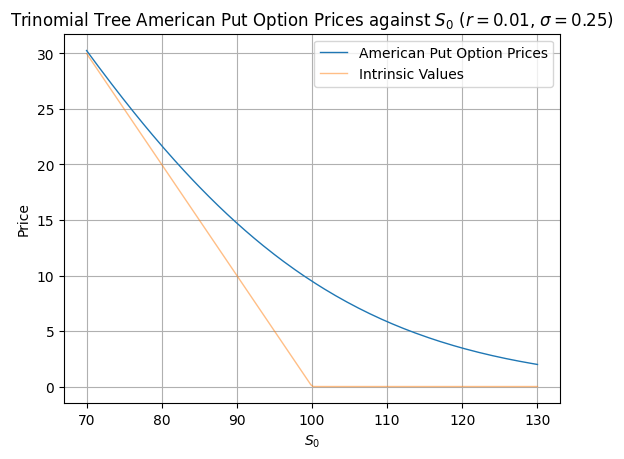

In [33]:
sigma = 0.25
r = 0.01

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.01_sigma_0.25.png', dpi = 300, bbox_inches="tight")

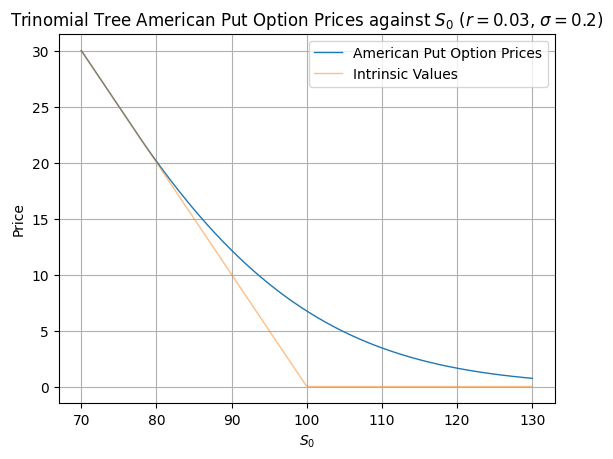

In [34]:
sigma = 0.2
r = 0.03

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.03_sigma_0.2.png', dpi = 300, bbox_inches="tight")

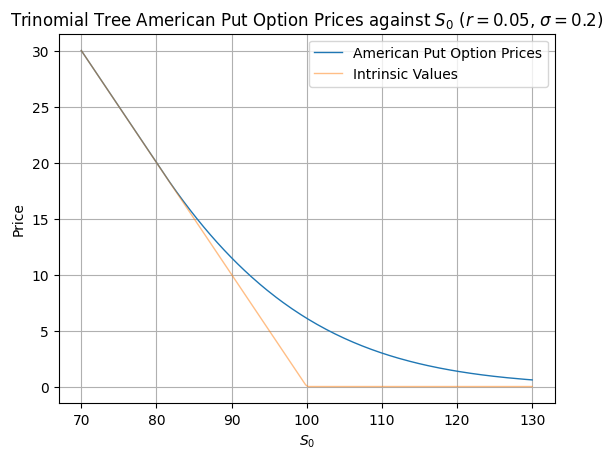

In [36]:
sigma = 0.2
r = 0.05

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.05_sigma_0.2.png', dpi = 300, bbox_inches="tight")

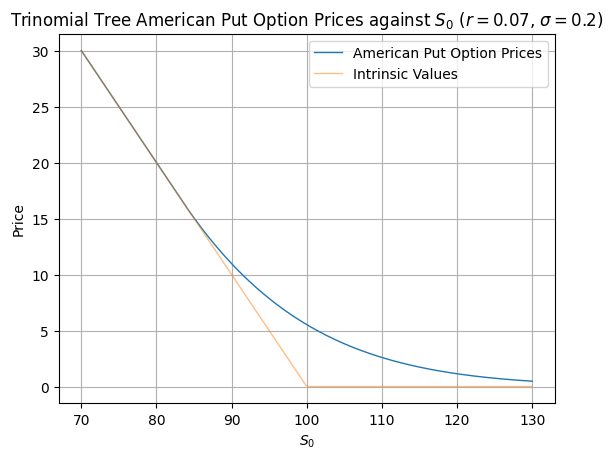

In [35]:
sigma = 0.2
r = 0.07

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.07_sigma_0.2.png', dpi = 300, bbox_inches="tight")

In the code above, we choose
- $K = 100$
- $N = 500$
- $T = 1$
- $\lambda = 1.25$

and deal with the following cases:

- $r \in \{0.01, 0.03, 0.05, 0.07 \}$ given $\sigma = 20 \%$
- $\sigma \in \{0.10, 0.15, 0.2, 0.25 \}$ given $r = 1 \%$

Define $S_0^*$ to be the exercise boundary. That is, one will exercise the American put option at time $t = 0$ if the initial price $S_0 \leq S_0^*$.

We can spot from the graphs above that the exercise boundaries for different combinations in $r$ and $\sigma$ are approximately:
|             | $\sigma = 0.2$ |
|:------:|:---:|
|$r = 0.01$ | $75$           |
|$r = 0.03$ | $82$           |
|$r = 0.05$ | $84$           |
|$r = 0.07$ | $86$           |

and

|                 | $r = 0.01$ |
|:---------------:|:----------:|
| $\sigma = 0.10$ |    $90$    |
| $\sigma = 0.15$ |    $83$    |
| $\sigma = 0.20$ |    $75$    |
| $\sigma = 0.25$ |    $70$    |

Hence, one may conclude that the exercise boundary

- increases as $r$ increases;
- decreases as $\sigma$ increases.

### Task 3: Lookback Options

The payoff function of a floating strike lookback put option is
$$
\sup_{0 \leq u \leq T} S_u - S_T
$$

and that of an American floating strike lookback put option is
$$
\sup_{0 \leq u \leq \tau} S_u - S_\tau
$$
where $\tau \leq T$ is the exercise time.

#### Part (a)

This is a typical case of **pricing a path-dependent option**, which has been discussed in Chapter 2 of the course. A suitable forward shooting grid (FSG) algorithm is displayed below:

1. We fix a tree model of stock price, where $u,m,d,q_u,q_m, q_d$ are given as at the beginning. The possible node values of the stock price are
        \begin{align*}
        s^n_k = S_0 u^k \text{ for } n = 0, 1, \dots, N \text{ and } k =-N,...,N
        \end{align*}
2. We define the auxiliary state process
        \begin{align*}
        M_n = \sup_{0\leq u \leq n} S_u
		\end{align*}
   so the payoff function for non-American can be expressed as
        \begin{align*}
        g(S_T, M_T) = M_T - S_T
        \end{align*}

3. We specify a grid for the auxiliary variable $M_n$. Since the initial stock price is $S_0$ and the largest possible price at time $n$ is $S_0 u^n$, the maximum price $M_n$ recorded between time zero and time $n$ must take value in the set
        \begin{align*}
        \{S_0, S_0 u, S_0 u^2, \dots, S_0 u^n\}
        \end{align*}
   Hence, we can construct the grid values $m^n_p$ for $M_n$ by
        \begin{align*}
        m^n_j = S_0 u^{j} \text{ for } j = 0, 1,\dots, n \text{ and } n = 0, 1, \dots, N
        \end{align*}
   In this way, the state of the system can be expressed as $(s^n_k, m^n_j)$. By definition, $M_n \geq S_n$, so the states need to satisfy
        \begin{align*}
        m^n_j \geq s^n_k \Leftrightarrow j\geq k
        \end{align*}
   Therefore, the admissible states at time $n$ are
        \begin{align*}
        k \in \{-n, \dots, n\},\;\;\; j \in \{\max(0,k), \dots, n\}
        \end{align*}

4. We investigate the evolution of the auxiliary variable as stock price changes.

   Suppose we are at time $n$ and state $(S_n, M_n) = (s^n_k, m^n_j)$. By definition, we have $M_{n+1} = \max(M_n, S_{n+1})$.

   From time $n$ to time $n+1$, if the stock price

   - moves upward, then $M_{n+1} = \max(m^n_j, s^{n+1}_{k+1}) \Rightarrow j_{\text{up}} = \max(j, k+1)$
   - does not move, then $M_{n+1} = \max(m^n_j, s^{n+1}_{k}) \Rightarrow j_{\text{mid}} = \max(j, k) = j$
   - moves downward, then $M_{n+1} = \max(m^n_j, s^{n+1}_{k - 1}) \Rightarrow j_{\text{down}} = \max(j, k - 1) = j$


   Hence, the shooting rule is
        \begin{align*}
        \phi_\text{up}(k,j) = \max(j, k+1)， \phi_\text{mid}(k,j) = \phi_\text{down}(k,j) = j
        \end{align*}

5. Let $V^n_{k,j}$ be the fair option price at time $n$ and state $(s^n_k, m^n_j)$. Then, applying the **backward induction algorithm**, the recursive equation is
        \begin{align*}
        V^n_{k,j} &= e^{-r\Delta t}\mathbb{E}^\mathbb{Q}\left[g(S_n, M_n) | \mathcal{F}_t\right] \\
        &= e^{-r\Delta t}\left[q_u V^{n+1}_{k+1, \phi_\text{up}(k,j)} + q_m V^{n+1}_{k, \phi_\text{mid}(k,j)} + q_d V^{n+1}_{k-1, \phi_\text{down}(k,j)}\right] \\
        &= e^{-r\Delta t}\left[q_u V^{n+1}_{k+1, \max(j , k+1)} + q_m V^{n+1}_{k, j} + q_d V^{n+1}_{k-1, j}\right]
        \end{align*}
   and the boundary condition is
        \begin{align*}
        V^N_{k,j} = m^N_j - s^N_k = S_0u^j - S_0u^k
        \end{align*}
   for $k \in \{-N, \dots, N\},\;\;\; j \in \{\max(0,k), \dots, N\}$.

For the American option, notice that the immediate exercise value is $m^n_j - s^n_k = S_0u^j - S_0u^k$, then the recursion equation becomes
        \begin{align*}
        V^n_{k,j} = \max \left(S_0u^j - S_0u^k,  e^{-r\Delta t}\left[q_u V^{n+1}_{k+1, \max(j , k+1)} + q_m V^{n+1}_{k, j} + q_d V^{n+1}_{k-1, j}\right] \right)
        \end{align*}

The complexity of this algorithm is $O(N^3)$.

In [19]:
def LookbackStockTree(S0, u, N):
    S = np.zeros((N + 1, 2 * N + 1))

    for n in range(N + 1):
        for k in range(-n, n + 1):
            S[n, k + N] = S0 * (u ** k)

    return S

def GetEuroLookbackPrice(S0, sigma, T, r, N, lamb):
    u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lamb, sigma, N, T, r)
    S = LookbackStockTree(S0, u, N)

    # V[n,k,j] := Fair option price at time n and state (s^n_k, m^n_j)
    V = np.zeros((N + 1, 2 * N + 1, N + 1))

    # Iintialise boundary condition
    n = N
    for k in range(-N, N + 1):
        S_N_k = S[n, k + N]
        for j in range(max(0, k), N + 1):
            M_N_j = S0 * (u ** j)
            V[n, k + N, j] = M_N_j - S_N_k

    # Backward induction algorithm
    for n in reversed(range(N)):
        for k in range(-n, n + 1):
            for j in range(max(0, k), n + 1):
                j_up = max(j, k + 1)
                j_mid = j
                j_down = j

                value = (
                    qu * V[n + 1, (k + 1) + N, j_up]
                    + qm * V[n + 1, k + N, j_mid]
                    + qd * V[n + 1, (k - 1) + N, j_down]
                ) / R

                V[n, k + N, j] = value

    return V[0, N, 0]

def GetAmerLookbackPrice(S0, sigma, T, r, N, lamb):
    u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lamb, sigma, N, T, r)
    S = LookbackStockTree(S0, u, N)

    # V[n,k,j] := Fair option price at time n and state (s^n_k, m^n_j)
    V = np.zeros((N + 1, 2 * N + 1, N + 1))

    # Iintialise boundary condition
    n = N
    for k in range(-N, N + 1):
        S_N_k = S[n, k + N]
        for j in range(max(0, k), N + 1):
            M_N_j = S0 * (u ** j)
            V[n, k + N, j] = M_N_j - S_N_k

    # Backward induction algorithm
    for n in reversed(range(N)):
        for k in range(-n, n + 1):
            S_n_k = S[n, k + N]
            for j in range(max(0, k), n + 1):
                j_up = max(j, k + 1)
                j_mid = j
                j_down = j

                value = (
                    qu * V[n + 1, (k + 1) + N, j_up]
                    + qm * V[n + 1, k + N, j_mid]
                    + qd * V[n + 1, (k - 1) + N, j_down]
                ) / R
                M_n_j = S0 * (u ** j)
                exer = M_n_j - S_n_k
                V[n, k + N, j] = max(exer, value)

    return V[0, N, 0]

In [20]:
import time
def LookbackPriceTable(S0, sigma, T, r, lamb, N_list):
    results = []

    for N in N_list:
        # European
        t0 = time.perf_counter()
        euro_price = GetEuroLookbackPrice(S0, sigma, T, r, N, lamb)
        t1 = time.perf_counter()

        # American
        amer_price = GetAmerLookbackPrice(S0, sigma, T, r, N, lamb)
        t2 = time.perf_counter()

        results.append({
            "N": N,
            "European Price": euro_price,
            "European Time (s)": t1 - t0,
            "American Price": amer_price,
            "American Time (s)": t2 - t1
        })

    return pd.DataFrame(results)

In [37]:
S0 = 100
sigma = 0.2
T = 1.0
r = 0.01
lamb = 1.25

N_list = np.arange(20,301,20)

df = LookbackPriceTable(S0, sigma, T, r, lamb, N_list)
print(df)

      N  European Price  European Time (s)  American Price  American Time (s)
0    20       13.485118           0.003924       13.630139           0.004572
1    40       14.274746           0.026688       14.414394           0.034019
2    60       14.641836           0.086904       14.779423           0.109608
3    80       14.865814           0.269660       15.002458           0.317439
4   100       15.020894           0.448569       15.156875           0.503803
5   120       15.136537           0.671969       15.272062           0.861811
6   140       15.227102           1.067559       15.362279           1.381887
7   160       15.300544           1.597677       15.435479           2.012829
8   180       15.361675           2.247843       15.496424           2.873489
9   200       15.413601           3.063205       15.548200           3.959685
10  220       15.458430           4.109897       15.592895           5.229651
11  240       15.497648           5.340209       15.631999      

In [24]:
N_list_2 = np.arange(320,500,20)

df_2 = LookbackPriceTable(S0, sigma, T, r, lamb, N_list_2)
print(df_2)

     N  European Price  European Time (s)  American Price  American Time (s)
0  320       15.616474          13.204438       15.750530          15.835160
1  340       15.639522          15.224773       15.773530          19.027755
2  360       15.660654          18.016556       15.794618          22.532484
3  380       15.680123          21.268312       15.814049          26.522638
4  400       15.698136          25.093559       15.832030          31.652326
5  420       15.714867          30.109134       15.848731          37.380211
6  440       15.730462          34.720889       15.864300          42.968397
7  460       15.745043          40.071508       15.878857          51.458043
8  480       15.758716          44.762066       15.892511          55.787716


In [ ]:
###